# Notebook 3: Machine Learning Modeling — Silver to Models/Gold
## Proyek Analisis Performa Kampanye Marketing

**Penanggung Jawab:** M Takhta Ali Sulthon (ML Engineer)

### Medallion Architecture
Notebook ini mengambil data dari **Silver Layer** (cleaned & features), melatih model, dan menyimpan hasilnya ke **Models** dan **Gold Layer**.
- Input: `silver/marketing_campaign_features`
- Output Model: `models/random_forest_classifier` dan `models/linear_regression`
- Output Data: `gold/predictions`


---
## Step 1: Setup & Load Data (Silver Layer)

In [1]:
import os, sys, warnings, glob as _glob
warnings.filterwarnings('ignore')

# ============================================================
# FIX Windows: Set environment variables sebelum import PySpark
# ============================================================
os.environ["JAVA_HOME"]   = r"C:\Program Files\Java\jdk-21.0.10"
os.environ["SPARK_HOME"]  = r"C:\spark\spark-4.1.1-bin-hadoop3"
os.environ["HADOOP_HOME"] = r"C:\Users\muham\OneDrive\Dokumen\Dokumen\BigData\bigdata6-marketing-analytics\hadoop"
_py4j = _glob.glob(os.path.join(os.environ["SPARK_HOME"], "python", "lib", "py4j-*.zip"))
sys.path.insert(0, os.path.join(os.environ["SPARK_HOME"], "python"))
if _py4j: sys.path.insert(0, _py4j[0])
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator, BinaryClassificationEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")

print("[OK] Library berhasil di-import!")
print(f"   JAVA_HOME   : {os.environ['JAVA_HOME']}")
print(f"   SPARK_HOME  : {os.environ['SPARK_HOME']}")
print(f"   HADOOP_HOME : {os.environ['HADOOP_HOME']}")

[OK] Library berhasil di-import!
   JAVA_HOME   : C:\Program Files\Java\jdk-21.0.10
   SPARK_HOME  : C:\spark\spark-4.1.1-bin-hadoop3
   HADOOP_HOME : C:\Users\muham\OneDrive\Dokumen\Dokumen\BigData\bigdata6-marketing-analytics\hadoop


In [2]:
# Konfigurasi MinIO
MINIO_ENDPOINT = "localhost:9000"
MINIO_ACCESS_KEY = "minioadmin"
MINIO_SECRET_KEY = "minioadmin123"
MINIO_BUCKET = "marketing-data"

BRONZE_CSV_PATH      = f"s3a://{MINIO_BUCKET}/bronze/marketing_campaign_performance.csv"
SILVER_CLEANED_PATH  = f"s3a://{MINIO_BUCKET}/silver/marketing_campaign_cleaned"
SILVER_FEATURES_PATH = f"s3a://{MINIO_BUCKET}/silver/marketing_campaign_features"
GOLD_PREDICTIONS_PATH          = f"s3a://{MINIO_BUCKET}/gold/predictions"
GOLD_CHANNEL_SUMMARY_PATH      = f"s3a://{MINIO_BUCKET}/gold/channel_performance_summary"
GOLD_PROFITABILITY_REPORT_PATH = f"s3a://{MINIO_BUCKET}/gold/campaign_profitability_report"
MODEL_RF_PATH = f"s3a://{MINIO_BUCKET}/models/random_forest_classifier"
MODEL_LR_PATH = f"s3a://{MINIO_BUCKET}/models/linear_regression"

spark = SparkSession.builder \
    .appName("Marketing_ML_Modeling") \
    .master("local[*]") \
    .config("spark.hadoop.fs.s3a.endpoint", f"http://{MINIO_ENDPOINT}") \
    .config("spark.hadoop.fs.s3a.access.key", MINIO_ACCESS_KEY) \
    .config("spark.hadoop.fs.s3a.secret.key", MINIO_SECRET_KEY) \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.aws.credentials.provider",
            "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .config("spark.hadoop.fs.s3a.threads.keepalivetime", "60") \
    .config("spark.hadoop.fs.s3a.connection.timeout", "200000") \
    .config("spark.hadoop.fs.s3a.connection.establish.timeout", "30000") \
    .config("spark.hadoop.fs.s3a.connection.ttl", "300000") \
    .config("spark.hadoop.fs.s3a.multipart.purge.age", "86400") \
    .config("spark.hadoop.fs.s3a.assumed.role.session.duration", "1800") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f'[OK] SparkSession dibuat! Versi: {spark.version}')

[OK] SparkSession dibuat! Versi: 4.1.1


In [3]:
df = spark.read.parquet(SILVER_FEATURES_PATH)
print(f'[OK] Data dimuat dari Silver Layer: {df.count():,} baris, {len(df.columns)} kolom')
df.printSchema()

[OK] Data dimuat dari Silver Layer: 10,000 baris, 22 kolom
root
 |-- CampaignID: string (nullable = true)
 |-- StartDate: date (nullable = true)
 |-- EndDate: date (nullable = true)
 |-- Channel: string (nullable = true)
 |-- Impressions: integer (nullable = true)
 |-- Clicks: integer (nullable = true)
 |-- Leads: integer (nullable = true)
 |-- Conversions: integer (nullable = true)
 |-- Cost_USD: double (nullable = true)
 |-- Revenue_USD: double (nullable = true)
 |-- ROI: double (nullable = true)
 |-- CTR: double (nullable = true)
 |-- CPC: double (nullable = true)
 |-- CPL: double (nullable = true)
 |-- CVR: double (nullable = true)
 |-- Lead_Rate: double (nullable = true)
 |-- ROAS: double (nullable = true)
 |-- Profit_USD: double (nullable = true)
 |-- Campaign_Duration: integer (nullable = true)
 |-- Start_Month: integer (nullable = true)
 |-- Start_DayOfWeek: integer (nullable = true)
 |-- is_profitable: integer (nullable = true)



In [4]:
# Preview data Silver Layer
print('--- Preview 5 baris pertama ---')
df.show(5, truncate=False)

# Verifikasi kolom fitur baru ada
required_cols = ['Revenue_USD', 'ROAS', 'Profit_USD', 'Lead_Rate', 
                 'Start_Month', 'Start_DayOfWeek', 'is_profitable']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    print(f'[WARN] Kolom berikut belum ada di Silver Layer, periksa NB02: {missing}')
else:
    print(f'[OK] Semua kolom fitur baru tersedia!')

# Distribusi label target (is_profitable)
print('\n--- Distribusi Label is_profitable ---')
label_dist = df.groupBy('is_profitable').count().orderBy('is_profitable')
label_dist.show()

# Cek class balance
label_pd = label_dist.toPandas()
if len(label_pd) < 2:
    print('[WARN] Hanya ada 1 kelas! Target tidak balanced. Periksa feature engineering NB02.')
else:
    total = label_pd['count'].sum()
    for _, row in label_pd.iterrows():
        pct = row['count'] / total * 100
        print(f'   Class {int(row["is_profitable"])}: {row["count"]:,} ({pct:.1f}%)')

# Statistik dasar
print('\n--- Statistik Deskriptif ---')
df.select(['Impressions','Clicks','Leads','Conversions','Cost_USD','Revenue_USD','ROI',
           'CTR','CPC','CPL','CVR','ROAS','Profit_USD','Campaign_Duration']).describe().show()

--- Preview 5 baris pertama ---
+----------+----------+----------+----------+-----------+------+-----+-----------+--------+-----------+----+--------------------+--------------------+-------------------+-------------------+-------------------+------------------+------------------+-----------------+-----------+---------------+-------------+
|CampaignID|StartDate |EndDate   |Channel   |Impressions|Clicks|Leads|Conversions|Cost_USD|Revenue_USD|ROI |CTR                 |CPC                 |CPL                |CVR                |Lead_Rate          |ROAS              |Profit_USD        |Campaign_Duration|Start_Month|Start_DayOfWeek|is_profitable|
+----------+----------+----------+----------+-----------+------+-----+-----------+--------+-----------+----+--------------------+--------------------+-------------------+-------------------+-------------------+------------------+------------------+-----------------+-----------+---------------+-------------+
|CAMP00001 |2025-04-13|2025-04-19|Search 

---
## Step 2: Persiapan Fitur (Feature Engineering)

In [5]:
# Encoding Channel (kategorikal → numerik)
channel_indexer = StringIndexer(inputCol='Channel', outputCol='Channel_Index', handleInvalid='keep')
channel_encoder = OneHotEncoder(inputCols=['Channel_Index'], outputCols=['Channel_Vec'])

# ── Fitur numerik (diperluas sesuai reference notebook) ──────────────────────
# Revenue_USD dan ROAS dimasukkan karena memberikan sinyal kuat untuk profitabilitas.
# ROI sendiri di-exclude untuk menghindari target leakage langsung.
numeric_features = [
    'Impressions', 'Clicks', 'Leads', 'Conversions',
    'Cost_USD', 'Revenue_USD',          # revenue langsung informatif
    'CTR', 'CPC', 'CPL', 'CVR',
    'Lead_Rate', 'ROAS', 'Profit_USD',  # derived KPIs
    'Campaign_Duration',
    'Start_Month', 'Start_DayOfWeek'    # fitur temporal
]

all_features = numeric_features + ['Channel_Vec']
assembler = VectorAssembler(inputCols=all_features, outputCol='features_raw', handleInvalid='skip')

# Standarisasi fitur
scaler = StandardScaler(inputCol='features_raw', outputCol='features', withStd=True, withMean=True)

print('[OK] Komponen pipeline disiapkan')
print(f'   Total fitur numerik : {len(numeric_features)}')
print(f'   Fitur numerik       : {numeric_features}')
print(f'   Fitur kategorikal   : [Channel → Channel_Vec (One-Hot)]')

[OK] Komponen pipeline disiapkan
   Total fitur numerik : 16
   Fitur numerik       : ['Impressions', 'Clicks', 'Leads', 'Conversions', 'Cost_USD', 'Revenue_USD', 'CTR', 'CPC', 'CPL', 'CVR', 'Lead_Rate', 'ROAS', 'Profit_USD', 'Campaign_Duration', 'Start_Month', 'Start_DayOfWeek']
   Fitur kategorikal   : [Channel → Channel_Vec (One-Hot)]


In [6]:
SEED = 42
train_data, test_data = df.randomSplit([0.8, 0.2], seed=SEED)
print(f'[OK] Data split selesai')
print(f'   Train set: {train_data.count():,} baris')
print(f'   Test  set: {test_data.count():,} baris')

# Cek distribusi kelas di masing-masing split
print('\n--- Distribusi kelas di Train ---')
train_data.groupBy('is_profitable').count().orderBy('is_profitable').show()
print('--- Distribusi kelas di Test ---')
test_data.groupBy('is_profitable').count().orderBy('is_profitable').show()

[OK] Data split selesai
   Train set: 8,079 baris
   Test  set: 1,921 baris

--- Distribusi kelas di Train ---
+-------------+-----+
|is_profitable|count|
+-------------+-----+
|            0| 4074|
|            1| 4005|
+-------------+-----+

--- Distribusi kelas di Test ---
+-------------+-----+
|is_profitable|count|
+-------------+-----+
|            0|  939|
|            1|  982|
+-------------+-----+



---
## Step 3: Random Forest Classifier
**Tujuan:** Memprediksi apakah suatu kampanye **profitable** (`is_profitable = 1`) atau tidak.

In [7]:
rf = RandomForestClassifier(
    labelCol='is_profitable',
    featuresCol='features',
    numTrees=100,        # ditingkatkan dari 50 → 100 untuk stabilitas
    maxDepth=10,         # ditingkatkan dari 5 → 10 untuk kapasitas model
    minInstancesPerNode=5,
    featureSubsetStrategy='sqrt',
    seed=SEED
)
rf_pipeline = Pipeline(stages=[channel_indexer, channel_encoder, assembler, scaler, rf])

print('[...] Melatih Random Forest Classifier (numTrees=100, maxDepth=10)...')
rf_model = rf_pipeline.fit(train_data)
print('[OK] Training selesai!')

[...] Melatih Random Forest Classifier (numTrees=100, maxDepth=10)...
[OK] Training selesai!


=== Evaluasi Random Forest Classifier ===
   Accuracy : 0.9953
   F1-Score : 0.9953
   AUC-ROC  : 0.9998


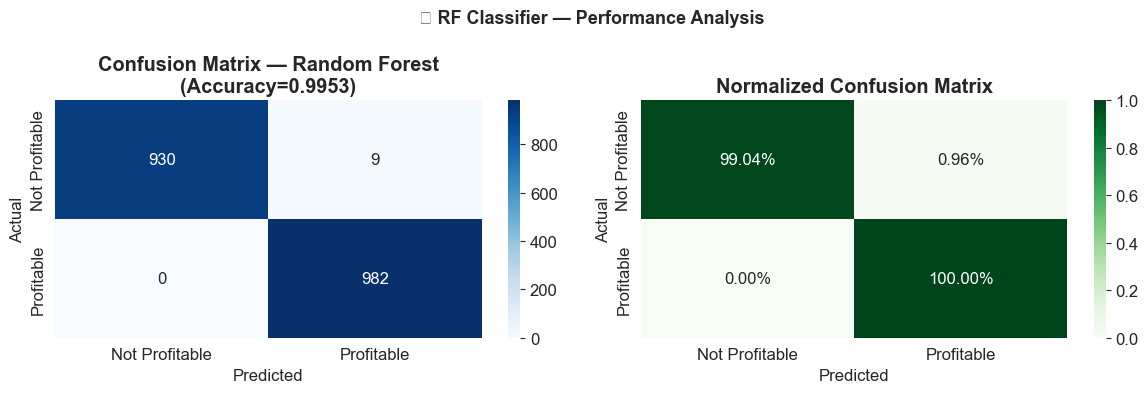


--- Classification Report ---
                precision    recall  f1-score   support

Not Profitable       1.00      0.99      1.00       939
    Profitable       0.99      1.00      1.00       982

      accuracy                           1.00      1921
     macro avg       1.00      1.00      1.00      1921
  weighted avg       1.00      1.00      1.00      1921



In [8]:
rf_predictions = rf_model.transform(test_data)

# Evaluasi
acc_eval  = MulticlassClassificationEvaluator(labelCol='is_profitable', predictionCol='prediction', metricName='accuracy')
f1_eval   = MulticlassClassificationEvaluator(labelCol='is_profitable', predictionCol='prediction', metricName='f1')
auc_eval  = BinaryClassificationEvaluator(labelCol='is_profitable', rawPredictionCol='rawPrediction', metricName='areaUnderROC')

rf_accuracy = acc_eval.evaluate(rf_predictions)
rf_f1       = f1_eval.evaluate(rf_predictions)
rf_auc      = auc_eval.evaluate(rf_predictions)

print('=== Evaluasi Random Forest Classifier ===')
print(f'   Accuracy : {rf_accuracy:.4f}')
print(f'   F1-Score : {rf_f1:.4f}')
print(f'   AUC-ROC  : {rf_auc:.4f}')

# ── Confusion Matrix (via pandas) ─────────────────────────────────────────────
rf_pdf = rf_predictions.select('is_profitable', 'prediction').toPandas()
rf_pdf['is_profitable'] = rf_pdf['is_profitable'].astype(int)
rf_pdf['prediction']    = rf_pdf['prediction'].astype(int)

from sklearn.metrics import confusion_matrix as sk_cm, classification_report
cm = sk_cm(rf_pdf['is_profitable'], rf_pdf['prediction'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Profitable','Profitable'],
            yticklabels=['Not Profitable','Profitable'])
axes[0].set_title(f'Confusion Matrix — Random Forest\n(Accuracy={rf_accuracy:.4f})', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Not Profitable','Profitable'],
            yticklabels=['Not Profitable','Profitable'])
axes[1].set_title('Normalized Confusion Matrix', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.suptitle('📌 RF Classifier — Performance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n--- Classification Report ---')
print(classification_report(rf_pdf['is_profitable'], rf_pdf['prediction'],
                             target_names=['Not Profitable', 'Profitable']))

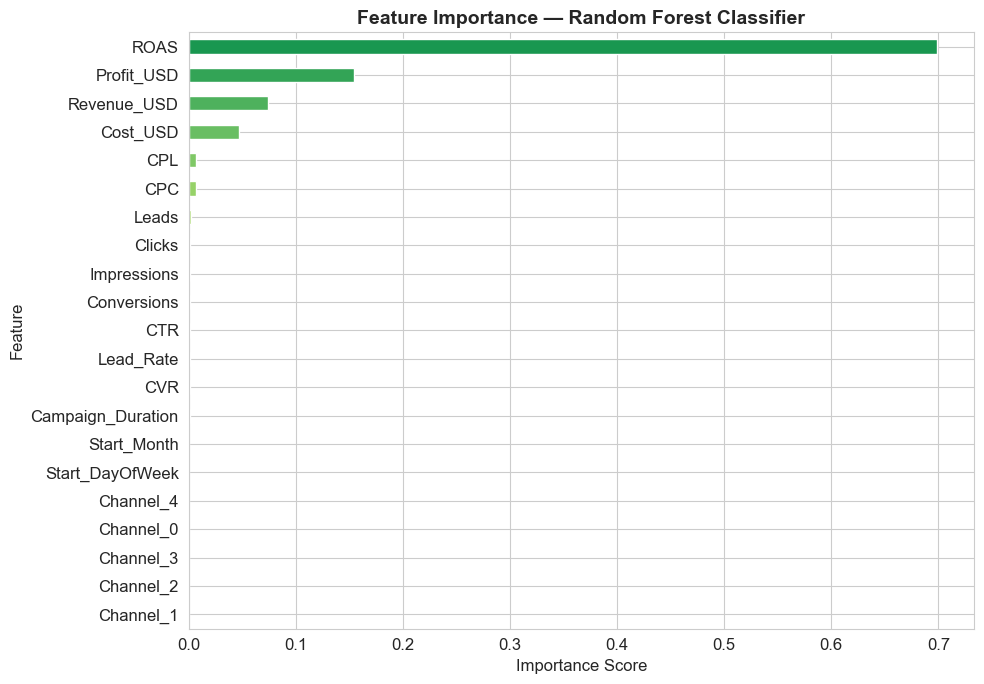


--- Top 5 Fitur Paling Penting ---
    feature  importance
       ROAS    0.698371
 Profit_USD    0.154024
Revenue_USD    0.074077
   Cost_USD    0.047326
        CPL    0.006730


In [9]:
# Feature Importance (dari model RandomForest di tahap akhir pipeline)
rf_stage = rf_model.stages[-1]  # RandomForestClassificationModel
importances = rf_stage.featureImportances.toArray()

# Nama fitur: numeric + channel one-hot vectors
n_ch_vecs = len(importances) - len(numeric_features)
feature_names = numeric_features + [f'Channel_{i}' for i in range(n_ch_vecs)]
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi_df)))
fi_df.plot(kind='barh', x='feature', y='importance', ax=plt.gca(), color=colors_fi, legend=False)
plt.title('Feature Importance — Random Forest Classifier', fontweight='bold', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\n--- Top 5 Fitur Paling Penting ---')
print(fi_df.sort_values('importance', ascending=False).head(5).to_string(index=False))

---
## Step 4: Linear Regression
**Tujuan:** Memprediksi **Revenue_USD** berdasarkan fitur kampanye.

In [10]:
lr = LinearRegression(
    labelCol='Revenue_USD',
    featuresCol='features',
    maxIter=10,
    regParam=0.1,
    elasticNetParam=0.5
)
lr_pipeline = Pipeline(stages=[channel_indexer, channel_encoder, assembler, scaler, lr])

print('[...] Melatih Linear Regression...')
lr_model = lr_pipeline.fit(train_data)
print('[OK] Training selesai!')

[...] Melatih Linear Regression...
[OK] Training selesai!


In [11]:
lr_predictions = lr_model.transform(test_data)

r2_eval   = RegressionEvaluator(labelCol='Revenue_USD', predictionCol='prediction', metricName='r2')
mae_eval  = RegressionEvaluator(labelCol='Revenue_USD', predictionCol='prediction', metricName='mae')
rmse_eval = RegressionEvaluator(labelCol='Revenue_USD', predictionCol='prediction', metricName='rmse')

lr_r2   = r2_eval.evaluate(lr_predictions)
lr_mae  = mae_eval.evaluate(lr_predictions)
lr_rmse = rmse_eval.evaluate(lr_predictions)

print('=== Evaluasi Linear Regression ===')
print(f'   R²   : {lr_r2:.4f}')
print(f'   MAE  : {lr_mae:.2f}')
print(f'   RMSE : {lr_rmse:.2f}')

=== Evaluasi Linear Regression ===
   R²   : 0.9998
   MAE  : 36.15
   RMSE : 47.58


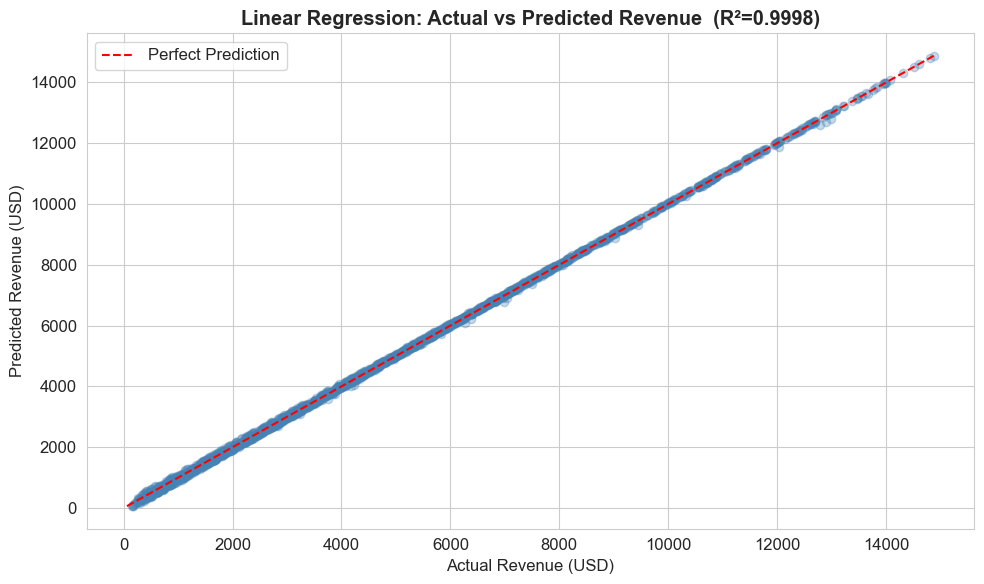

In [12]:
# Visualisasi Actual vs Predicted Revenue
lr_pdf = lr_predictions.select('Revenue_USD', 'prediction').toPandas()

plt.figure(figsize=(10, 6))
plt.scatter(lr_pdf['Revenue_USD'], lr_pdf['prediction'], alpha=0.3, color='steelblue')
lim_min = min(lr_pdf['Revenue_USD'].min(), lr_pdf['prediction'].min())
lim_max = max(lr_pdf['Revenue_USD'].max(), lr_pdf['prediction'].max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Revenue (USD)')
plt.ylabel('Predicted Revenue (USD)')
plt.title(f'Linear Regression: Actual vs Predicted Revenue  (R²={lr_r2:.4f})', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 5: Simpan Model & Prediksi ke MinIO (Models & Gold Layer)

In [13]:
print('[...] Menyimpan model dan prediksi ke MinIO...')

# Simpan model
rf_model.write().overwrite().save(MODEL_RF_PATH)
lr_model.write().overwrite().save(MODEL_LR_PATH)
print(f'[OK] Model RF disimpan di: {MODEL_RF_PATH}')
print(f'[OK] Model LR disimpan di: {MODEL_LR_PATH}')

# Prediksi pada seluruh dataset (df) untuk Gold Layer
rf_full = rf_model.transform(df)
lr_full = lr_model.transform(df)

# rf_save: include semua kolom KPI yang dibutuhkan NB04
rf_save = rf_full.select(
    'CampaignID', 'Channel', 'is_profitable', 'prediction',
    'Impressions', 'Clicks', 'Leads', 'Conversions',
    'Revenue_USD', 'Cost_USD', 'ROI',
    'CTR', 'CPC', 'CPL', 'CVR', 'Lead_Rate',
    'ROAS', 'Profit_USD',                       # ← tambahan untuk NB04
    'Campaign_Duration', 'Start_Month', 'Start_DayOfWeek'
).withColumnRenamed('prediction', 'rf_prediction')

lr_save = lr_full.select(
    'CampaignID', 'prediction'
).withColumnRenamed('prediction', 'lr_predicted_revenue')

predictions_combined = rf_save.join(lr_save, on='CampaignID', how='inner')

# --- Data Governance: Schema Validation ---
expected_columns = {
    'CampaignID', 'Channel', 'is_profitable', 'rf_prediction',
    'Impressions', 'Clicks', 'Leads', 'Conversions',
    'Revenue_USD', 'Cost_USD', 'ROI',
    'CTR', 'CPC', 'CPL', 'CVR', 'Lead_Rate',
    'ROAS', 'Profit_USD',
    'Campaign_Duration', 'Start_Month', 'Start_DayOfWeek',
    'lr_predicted_revenue'
}
actual_columns = set(predictions_combined.columns)
if not expected_columns.issubset(actual_columns):
    missing_cols = expected_columns - actual_columns
    raise ValueError(f'[ERROR] Schema Validation Failed: Missing columns {missing_cols}')
print('[OK] Data Governance: Schema validation passed.')

predictions_combined.write.mode('overwrite').parquet(GOLD_PREDICTIONS_PATH)
print(f'[OK] Gold Prediksi tersimpan di: {GOLD_PREDICTIONS_PATH}')
print(f'   Jumlah baris : {predictions_combined.count():,}')
print(f'   Jumlah kolom : {len(predictions_combined.columns)}')
print(f'   Kolom        : {predictions_combined.columns}')

[...] Menyimpan model dan prediksi ke MinIO...
[OK] Model RF disimpan di: s3a://marketing-data/models/random_forest_classifier
[OK] Model LR disimpan di: s3a://marketing-data/models/linear_regression
[OK] Data Governance: Schema validation passed.
[OK] Gold Prediksi tersimpan di: s3a://marketing-data/gold/predictions
   Jumlah baris : 10,000
   Jumlah kolom : 22
   Kolom        : ['CampaignID', 'Channel', 'is_profitable', 'rf_prediction', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue_USD', 'Cost_USD', 'ROI', 'CTR', 'CPC', 'CPL', 'CVR', 'Lead_Rate', 'ROAS', 'Profit_USD', 'Campaign_Duration', 'Start_Month', 'Start_DayOfWeek', 'lr_predicted_revenue']


---
## Step 6: Ringkasan Hasil Model

=== Ringkasan Performa Model ===
                   Model                                       Task                           Metrik Utama
Random Forest Classifier Klasifikasi Profitabilitas (is_profitable) Accuracy=0.9953, F1=0.9953, AUC=0.9998
       Linear Regression             Prediksi Revenue (Revenue_USD)       R²=0.9998, MAE=36.15, RMSE=47.58


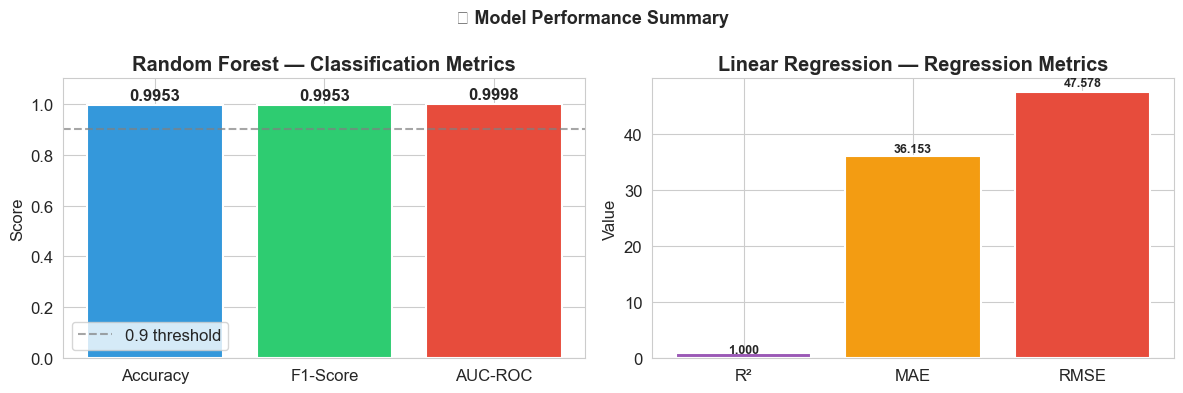

In [14]:
summary = pd.DataFrame({
    'Model': ['Random Forest Classifier', 'Linear Regression'],
    'Task': ['Klasifikasi Profitabilitas (is_profitable)', 'Prediksi Revenue (Revenue_USD)'],
    'Metrik Utama': [
        f'Accuracy={rf_accuracy:.4f}, F1={rf_f1:.4f}, AUC={rf_auc:.4f}',
        f'R²={lr_r2:.4f}, MAE={lr_mae:.2f}, RMSE={lr_rmse:.2f}'
    ]
})

print('=== Ringkasan Performa Model ===')
print(summary.to_string(index=False))

# Visualisasi ringkasan performa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# RF metrics bar
rf_metrics = {'Accuracy': rf_accuracy, 'F1-Score': rf_f1, 'AUC-ROC': rf_auc}
axes[0].bar(rf_metrics.keys(), rf_metrics.values(),
            color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=0.9, color='gray', linestyle='--', alpha=0.7, label='0.9 threshold')
for i, (k, v) in enumerate(rf_metrics.items()):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].set_title('Random Forest — Classification Metrics', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend()

# LR metrics bar
lr_metrics_norm = {'R² Score': lr_r2, 'MAE (norm)': 1 - lr_mae/10000, 'RMSE (norm)': 1 - lr_rmse/10000}
axes[1].bar(['R²', 'MAE', 'RMSE'],
            [lr_r2, lr_mae, lr_rmse],
            color=['#9b59b6', '#f39c12', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Linear Regression — Regression Metrics', fontweight='bold')
axes[1].set_ylabel('Value')
for i, v in enumerate([lr_r2, lr_mae, lr_rmse]):
    axes[1].text(i, v * 1.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('📊 Model Performance Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
spark.stop()
print('[OK] SparkSession dihentikan')